In [2]:
!pip install kagglehub ultralytics opencv-python matplotlib albumentations tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00


In [3]:
import kagglehub
import os
dataset_path = kagglehub.dataset_download("banuprasadb/visdrone-dataset")
visdrone_dir = os.path.join(dataset_path, "VisDrone_Dataset")
print("Top-level folders inside VisDrone_Dataset:", os.listdir(visdrone_dir))



Using Colab cache for faster access to the 'visdrone-dataset' dataset.
Top-level folders inside VisDrone_Dataset: ['VisDrone2019-DET-test-challenge', 'VisDrone2019-DET-test-dev', 'VisDrone2019-DET-train', 'visdrone.yaml', 'VisDrone2019-DET-val']


In [4]:
import os
import kagglehub

# This is where kagglehub actually puts the files
actual_data_path = kagglehub.dataset_download("banuprasadb/visdrone-dataset")
print(f"Dataset is at: {actual_data_path}")
print("Folders inside:", os.listdir(actual_data_path))

Using Colab cache for faster access to the 'visdrone-dataset' dataset.
Dataset is at: /kaggle/input/visdrone-dataset
Folders inside: ['VisDrone_Dataset']


In [5]:
import cv2
from albumentations import Compose, HorizontalFlip, RandomBrightnessContrast
from tqdm import tqdm
import shutil

In [6]:
train_images_dir = os.path.join(visdrone_dir, "VisDrone2019-DET-train/images")
train_labels_dir = os.path.join(visdrone_dir, "VisDrone2019-DET-train/labels")

In [7]:
aug_train_images_dir = "/content/VisDrone_Preprocessed/train/images"
aug_train_labels_dir = "/content/VisDrone_Preprocessed/train/labels"

os.makedirs(aug_train_images_dir, exist_ok=True)
os.makedirs(aug_train_labels_dir, exist_ok=True)

In [8]:
transform = Compose([
    RandomBrightnessContrast(p=0.3),
    HorizontalFlip(p=0.5)  # Note: horizontal flip requires label transform if you want full accuracy
])

print("Augmenting training images and copying labels...")
for img_file in tqdm(os.listdir(train_images_dir)):
    img_path = os.path.join(train_images_dir, img_file)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Augment image
    augmented = transform(image=img)['image']
    cv2.imwrite(os.path.join(aug_train_images_dir, img_file), augmented)

    # Copy corresponding YOLO label file (filename must match image)
    label_file = img_file.replace(".jpg", ".txt")
    shutil.copy(os.path.join(train_labels_dir, label_file), os.path.join(aug_train_labels_dir, label_file))


Augmenting training images and copying labels...


100%|██████████| 6471/6471 [03:39<00:00, 29.45it/s]


In [9]:
augmented_yaml = f"""
train: {aug_train_images_dir}
val: {os.path.join(visdrone_dir, "VisDrone2019-DET-val/images")}
test: {os.path.join(visdrone_dir, "VisDrone2019-DET-test-dev")}

nc: 10
names: ['pedestrian','people','bicycle','car','van','truck','tricycle','awning-tricycle','bus','motor']
"""

yaml_path = "/content/fixed_visdrone_aug.yaml"
with open(yaml_path, "w") as f:
    f.write(augmented_yaml)

print("fixed_visdrone_aug.yaml created at:", yaml_path)


fixed_visdrone_aug.yaml created at: /content/fixed_visdrone_aug.yaml


In [10]:
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
model = YOLO("yolov8s.pt")


In [12]:
model.train(
    data=yaml_path,
    epochs=30,                  # total epochs
    imgsz=640,
    batch=16,                   # GPU batch size
    project="runs/train",       # output folder
    name="visdrone_v8_aug",     # folder name for this run
    device="cuda",              # use GPU
    resume=False                # set True to continue from last checkpoint
)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fixed_visdrone_aug.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_v8_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dafa57a4fe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [13]:
import matplotlib.pyplot as plt

In [14]:
val_images_dir = os.path.join(visdrone_dir, "VisDrone2019-DET-val/images")
test_image = os.path.join(val_images_dir, os.listdir(val_images_dir)[0])

In [17]:
model = YOLO("/content/runs/detect/runs/train/visdrone_v8_aug/weights/best.pt")

In [18]:
results = model.predict(test_image, device="cuda")


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000086_01443_d_0000004.jpg: 384x640 42 pedestrians, 46.2ms
Speed: 2.9ms preprocess, 46.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


In [19]:
human_count = sum([1 for cls in results[0].boxes.cls if int(cls) == 0])
car_count   = sum([1 for cls in results[0].boxes.cls if int(cls) == 3])
print(f"Humans detected: {human_count}")
print(f"Cars detected: {car_count}")

Humans detected: 42
Cars detected: 0


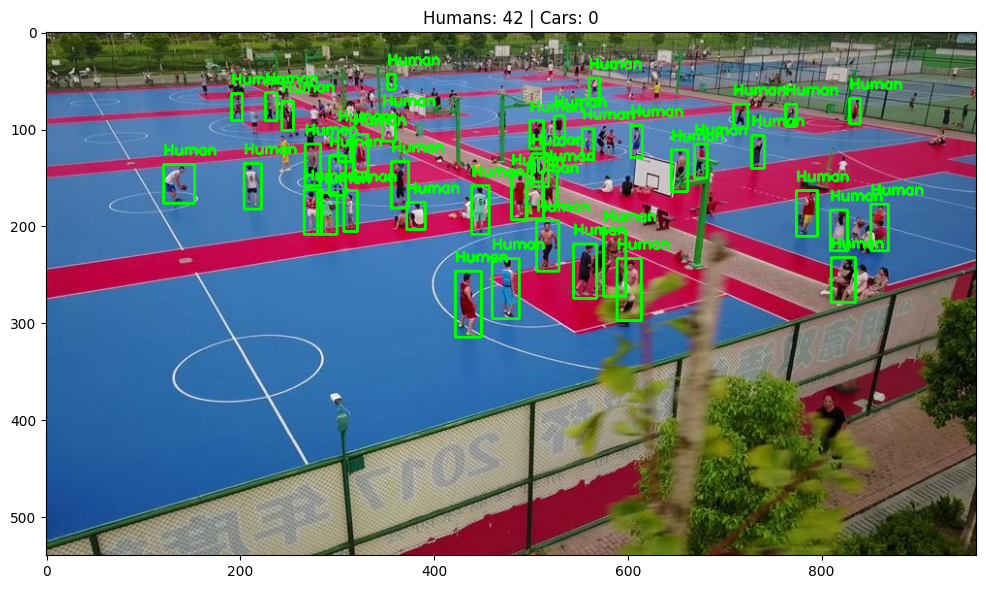

In [20]:
img = cv2.imread(test_image)
for box, cls in zip(results[0].boxes.xyxy, results[0].boxes.cls):
    x1, y1, x2, y2 = map(int, box)
    label = "Human" if int(cls)==0 else ("Car" if int(cls)==3 else "Other")
    color = (0,255,0) if label=="Human" else (0,0,255)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(12,8))
plt.imshow(img[:,:,::-1])
plt.title(f"Humans: {human_count} | Cars: {car_count}")
plt.show()


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000086_01443_d_0000004.jpg: 384x640 42 pedestrians, 11.1ms
Speed: 2.8ms preprocess, 11.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
0000086_01443_d_0000004.jpg: Humans=42, Cars=0


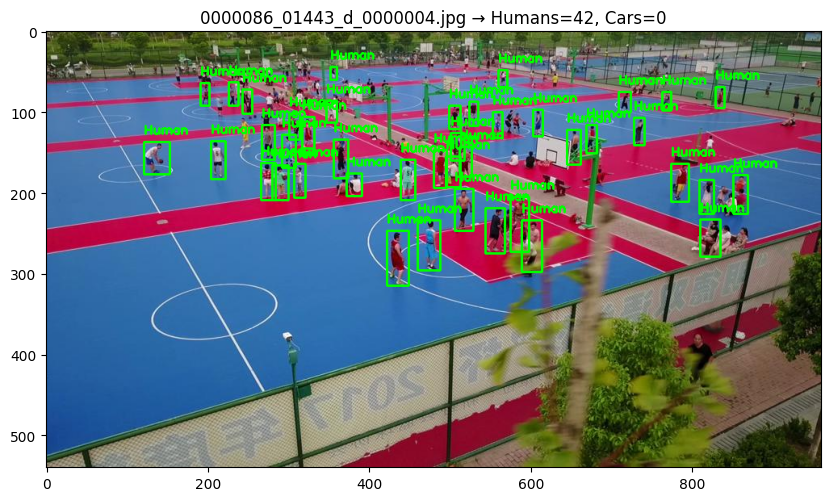


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000277_01401_d_0000546.jpg: 384x640 5 pedestrians, 1 people, 1 bicycle, 15 cars, 1 van, 12.4ms
Speed: 3.1ms preprocess, 12.4ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
0000277_01401_d_0000546.jpg: Humans=5, Cars=15


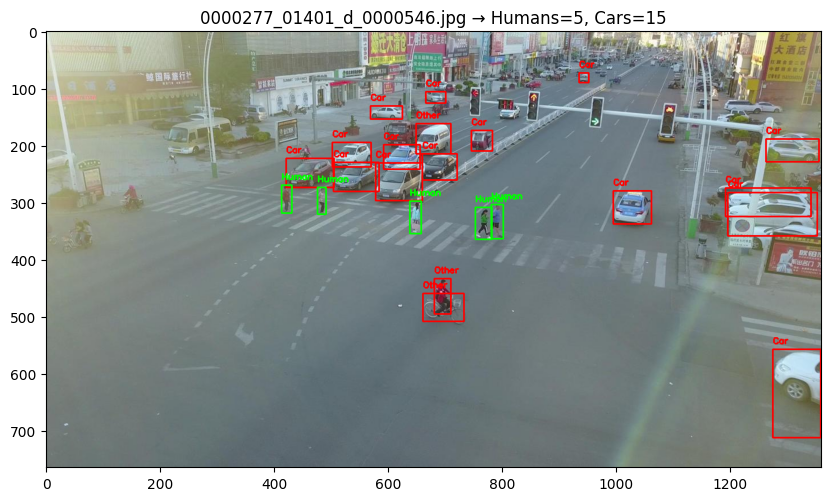


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000358_03333_d_0000697.jpg: 384x640 2 pedestrians, 2 peoples, 35 cars, 1 van, 1 truck, 1 tricycle, 1 motor, 10.8ms
Speed: 4.2ms preprocess, 10.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
0000358_03333_d_0000697.jpg: Humans=2, Cars=35


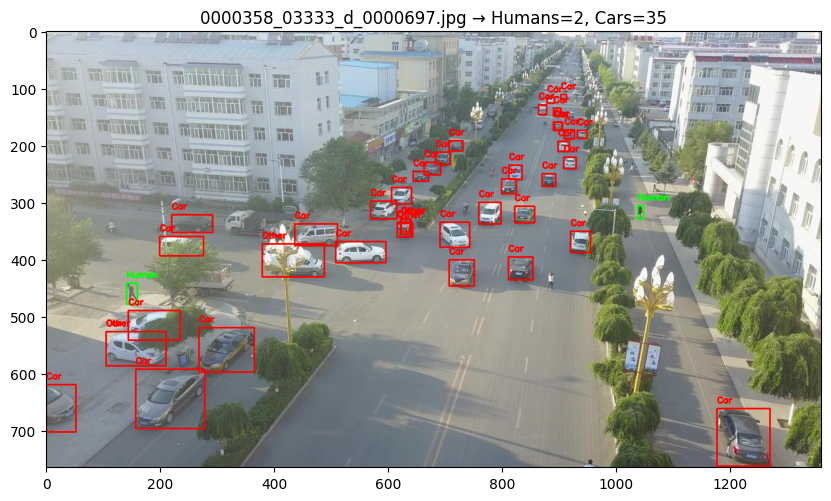


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000360_07253_d_0000750.jpg: 384x640 2 pedestrians, 1 people, 12 cars, 2 vans, 3 motors, 10.9ms
Speed: 3.2ms preprocess, 10.9ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
0000360_07253_d_0000750.jpg: Humans=2, Cars=12


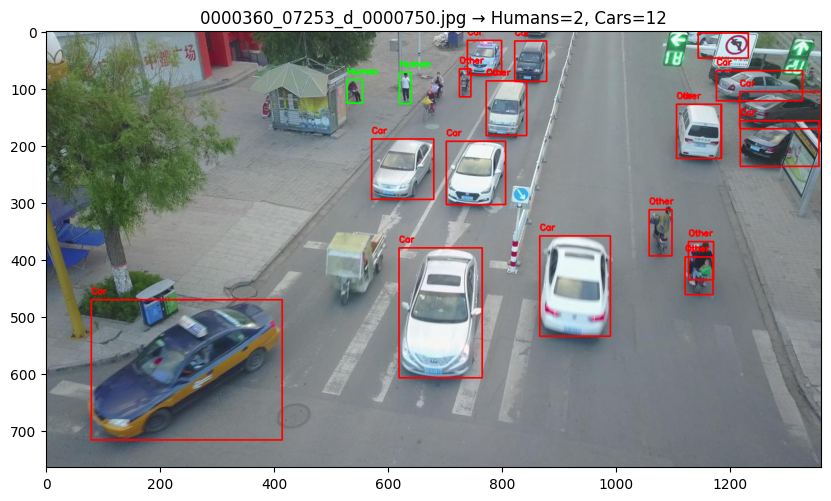


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000237_00001_d_0000001.jpg: 384x640 4 cars, 11.2ms
Speed: 2.8ms preprocess, 11.2ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
0000237_00001_d_0000001.jpg: Humans=0, Cars=4


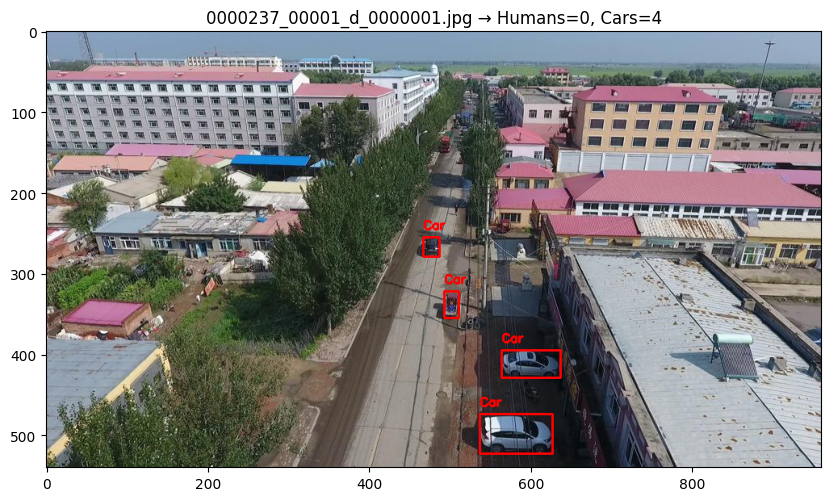

In [21]:
sample_images = os.listdir(val_images_dir)[:5]  # first 5 images
for img_file in sample_images:
    img_path = os.path.join(val_images_dir, img_file)
    results = model.predict(img_path, device="cuda")

    human_count = sum([1 for cls in results[0].boxes.cls if int(cls) == 0])
    car_count   = sum([1 for cls in results[0].boxes.cls if int(cls) == 3])

    print(f"{img_file}: Humans={human_count}, Cars={car_count}")
    img = cv2.imread(img_path)
    for box, cls in zip(results[0].boxes.xyxy, results[0].boxes.cls):
        x1, y1, x2, y2 = map(int, box)
        label = "Human" if int(cls)==0 else ("Car" if int(cls)==3 else "Other")
        color = (0,255,0) if label=="Human" else (0,0,255)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    plt.figure(figsize=(10,6))
    plt.imshow(img[:,:,::-1])
    plt.title(f"{img_file} → Humans={human_count}, Cars={car_count}")
    plt.show()